In [ ]:
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.models import VAE, IWAE, VampPriorVAE

import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision as tv

In [ ]:
from vae_project.models.latent_analysis import (
    get_latent_codes,
    compute_active_units,
    kl_from_mu_logvar,
    linear_probe,
    plot_latent_2d,
    latent_traversal,
    mcmc_relaxed_interpolation,
    decode_grid,
)

In [ ]:
def load_all_models(device):
    MODELS = {}

    # --- 1) VAE ---
    vae = VAE((3,32,64,128), input_size=(32,32), latent_dim=16, h_dim=64, recon_dist='bce')
    vae.load_state_dict(torch.load("./checkpoints/vae_final.pt", map_location=device))
    vae.to(device).eval()
    MODELS["VAE"] = vae

    # --- 2) IWAE ---
    iwae = IWAE((3,32,64,128), input_size=(32,32), latent_dim=16, h_dim=64)
    iwae.load_state_dict(torch.load("./checkpoints/iwae_final.pt", map_location=device))
    iwae.to(device).eval()
    MODELS["IWAE"] = iwae

    # --- 3) VampPriorVAE ---
    vamp = VampPriorVAE(
        encoder_or_channel_nums=(3,32,64,128),
        input_size=(32,32),
        input_channels=3,
        latent_dim=16,
        num_components=100,
        h_dim=64,
        act_fn=torch.nn.ReLU(),
        out_act=torch.nn.Sigmoid(),
        normalize=False,
        use_pseudo_net=False,
        device=device,
    )
    vamp.load_state_dict(torch.load("./checkpoints/vampprior_final.pt", map_location=device))
    vamp.to(device).eval()
    MODELS["VampPrior"] = vamp

    print("Loaded...")
    return MODELS


In [ ]:
device = default_device

batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

train_ds, val_ds = get_dataset("../data"), get_dataset("../data", train=False)
val_dl = DataLoader(val_ds, batch_size=256, shuffle=False, collate_fn=collate_fn)


In [ ]:
MODELS = load_all_models(device)

latents = {}  # name -> (mu, logvar, z, labels)

for name, model in MODELS.items():
    print(f"\nExtracting latents for {name}...")
    mu, logvar, z, labels = get_latent_codes(model, val_dl, device)
    latents[name] = (mu, logvar, z, labels)


✓ Model initialization validated successfully for colored MNIST
Loaded...

Extracting latents for VAE...

Extracting latents for IWAE...

Extracting latents for VampPrior...


In [ ]:
# Normalize shapes as IWAE returns (B, 1, D)
for name, (mu, logvar, z, labels) in latents.items():
    if z.ndim == 3 and z.shape[1] == 1:
        print(f"Fixing IWAE shape for {name}: {z.shape} -> squeezing K=1")
        mu = mu.squeeze(1)
        logvar = logvar.squeeze(1)
        z = z.squeeze(1)
        latents[name] = (mu, logvar, z, labels)


Fixing IWAE shape for IWAE: torch.Size([10000, 1, 16]) -> squeezing K=1


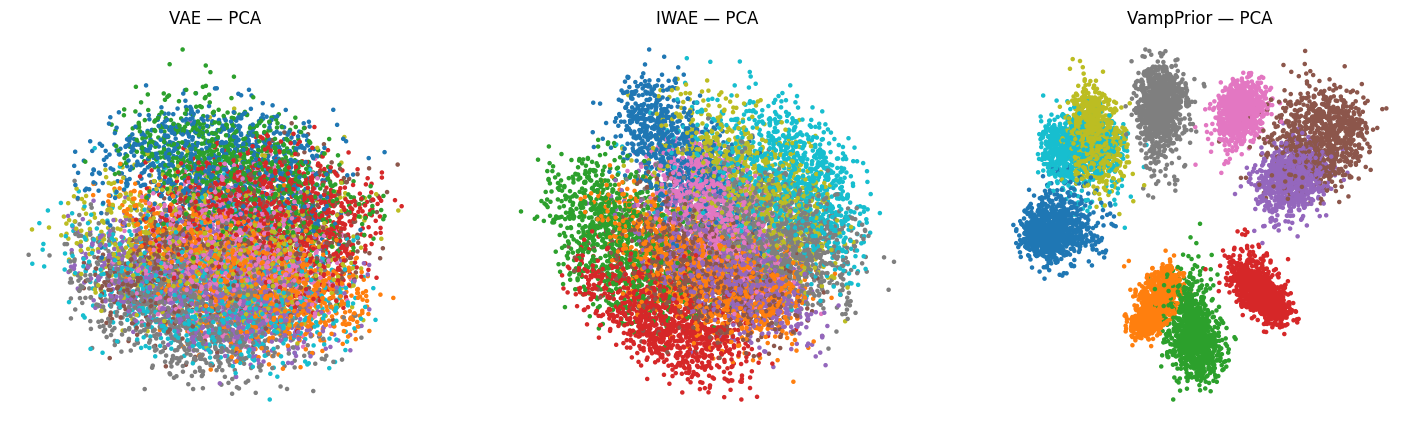

In [ ]:
plt.figure(figsize=(18,5))

for i, (name, (mu, logvar, z, labels)) in enumerate(latents.items()):
    from sklearn.decomposition import PCA
    z2 = PCA(n_components=2).fit_transform(z.numpy())

    plt.subplot(1,3,i+1)
    plt.scatter(z2[:,0], z2[:,1], c=labels.numpy(), s=5, cmap="tab10")
    plt.title(f"{name} — PCA")
    plt.axis("off")

plt.show()


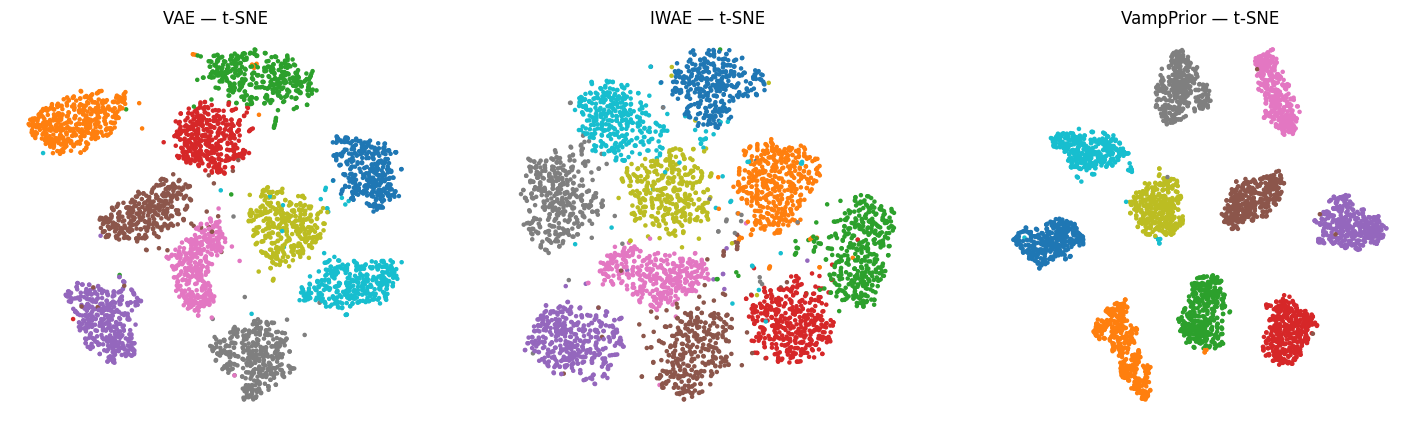

In [ ]:
plt.figure(figsize=(18,5))

from sklearn.manifold import TSNE

for i, (name, (mu, logvar, z, labels)) in enumerate(latents.items()):
    z2 = TSNE(n_components=2, perplexity=30).fit_transform(z[:4000].numpy())

    plt.subplot(1,3,i+1)
    plt.scatter(z2[:,0], z2[:,1], c=labels[:4000].numpy(), s=5, cmap="tab10")
    plt.title(f"{name} — t-SNE")
    plt.axis("off")

plt.show()


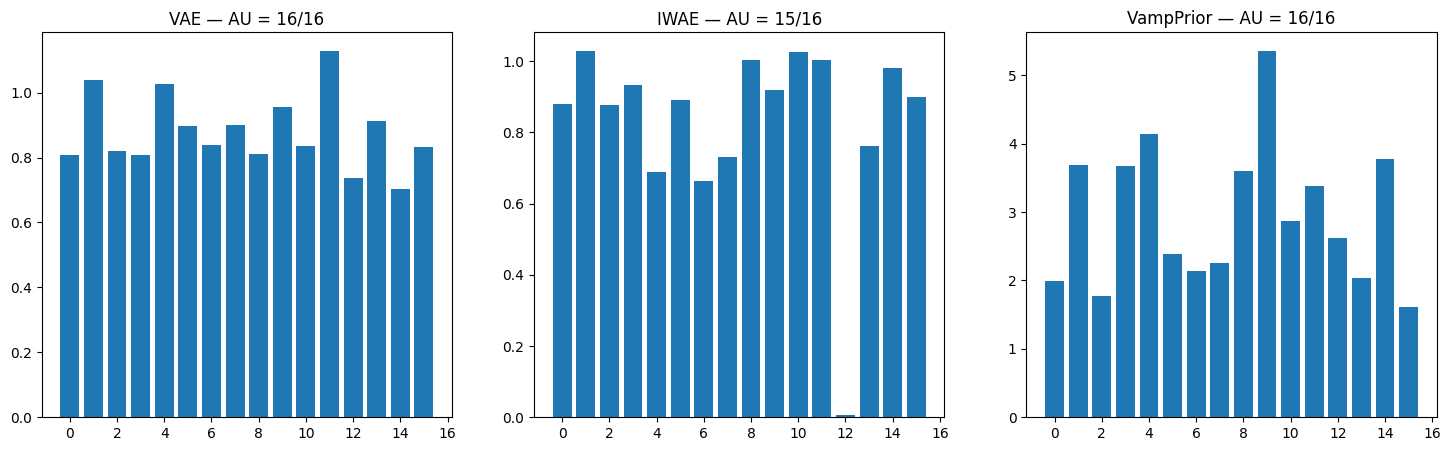

In [ ]:
plt.figure(figsize=(18,5))

for i, (name, (mu, logvar, z, labels)) in enumerate(latents.items()):
    var, active = compute_active_units(mu)
    plt.subplot(1,3,i+1)
    plt.bar(range(len(var)), var)
    plt.title(f"{name} — AU = {active}/{len(var)}")

plt.show()


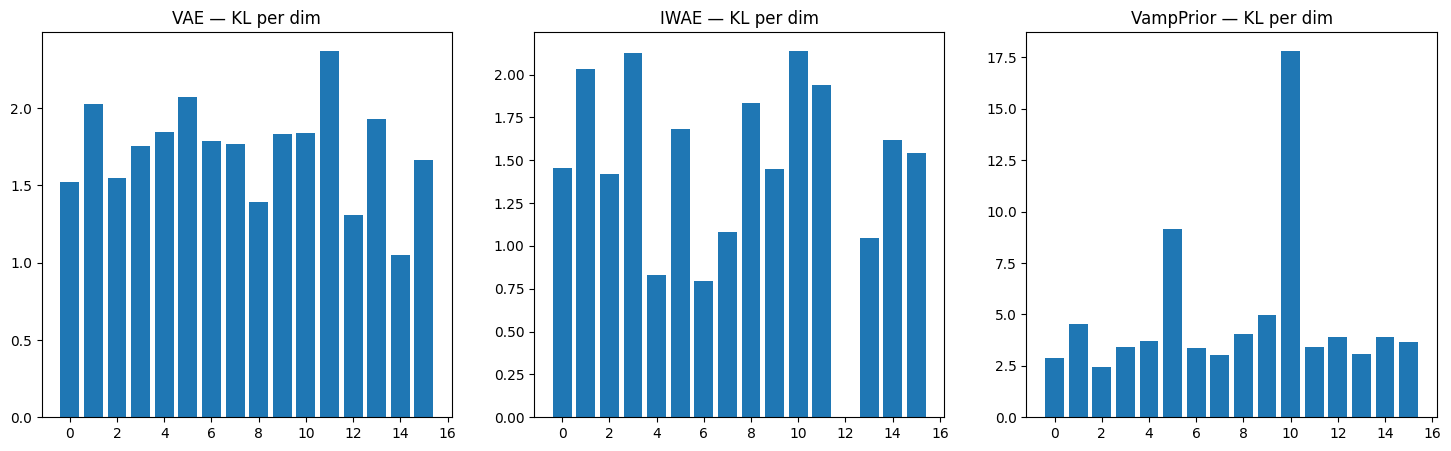

In [ ]:
plt.figure(figsize=(18,5))

for i, (name, (mu, logvar, z, labels)) in enumerate(latents.items()):
    kl = kl_from_mu_logvar(mu, logvar).numpy()
    
    plt.subplot(1, 3, i+1)
    plt.bar(range(len(kl)), kl)
    plt.title(f"{name} — KL per dim")

plt.show()



In [ ]:
for name, (mu, logvar, z, labels) in latents.items():
    clf, acc = linear_probe(z.numpy(), labels.numpy())
    print(f"{name:10s} linear probe accuracy: {acc:.3f}")



VAE        linear probe accuracy: 0.994
IWAE       linear probe accuracy: 0.991
VampPrior  linear probe accuracy: 1.000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-66.780495..4.0729904].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-68.023964..4.0689883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-67.25598..3.3328514].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-67.76252..3.3777452].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-72.00221..3.87394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-68.645035..3.6894662].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-71.05112..3.7

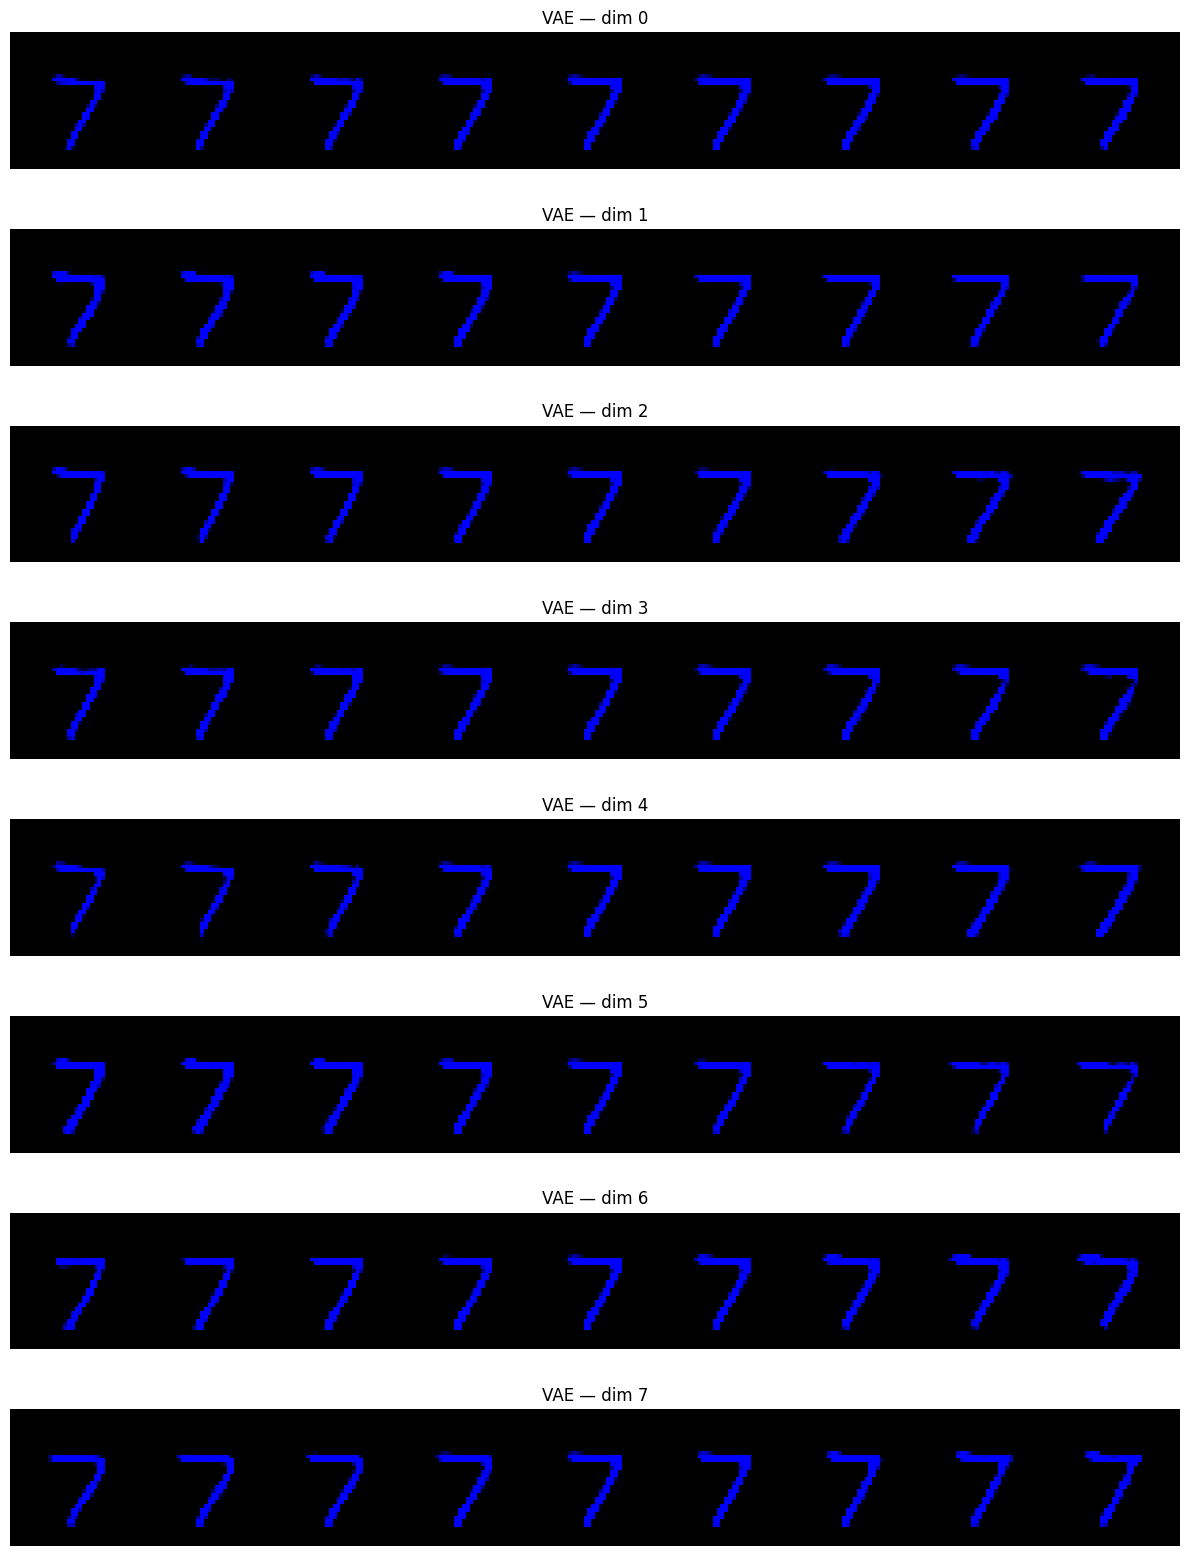

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-92.213104..4.2466645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-98.54036..4.782173].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-92.18612..4.619011].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-108.031395..4.8105984].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-95.53216..4.143128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-99.66912..4.133113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-93.57169..4.150

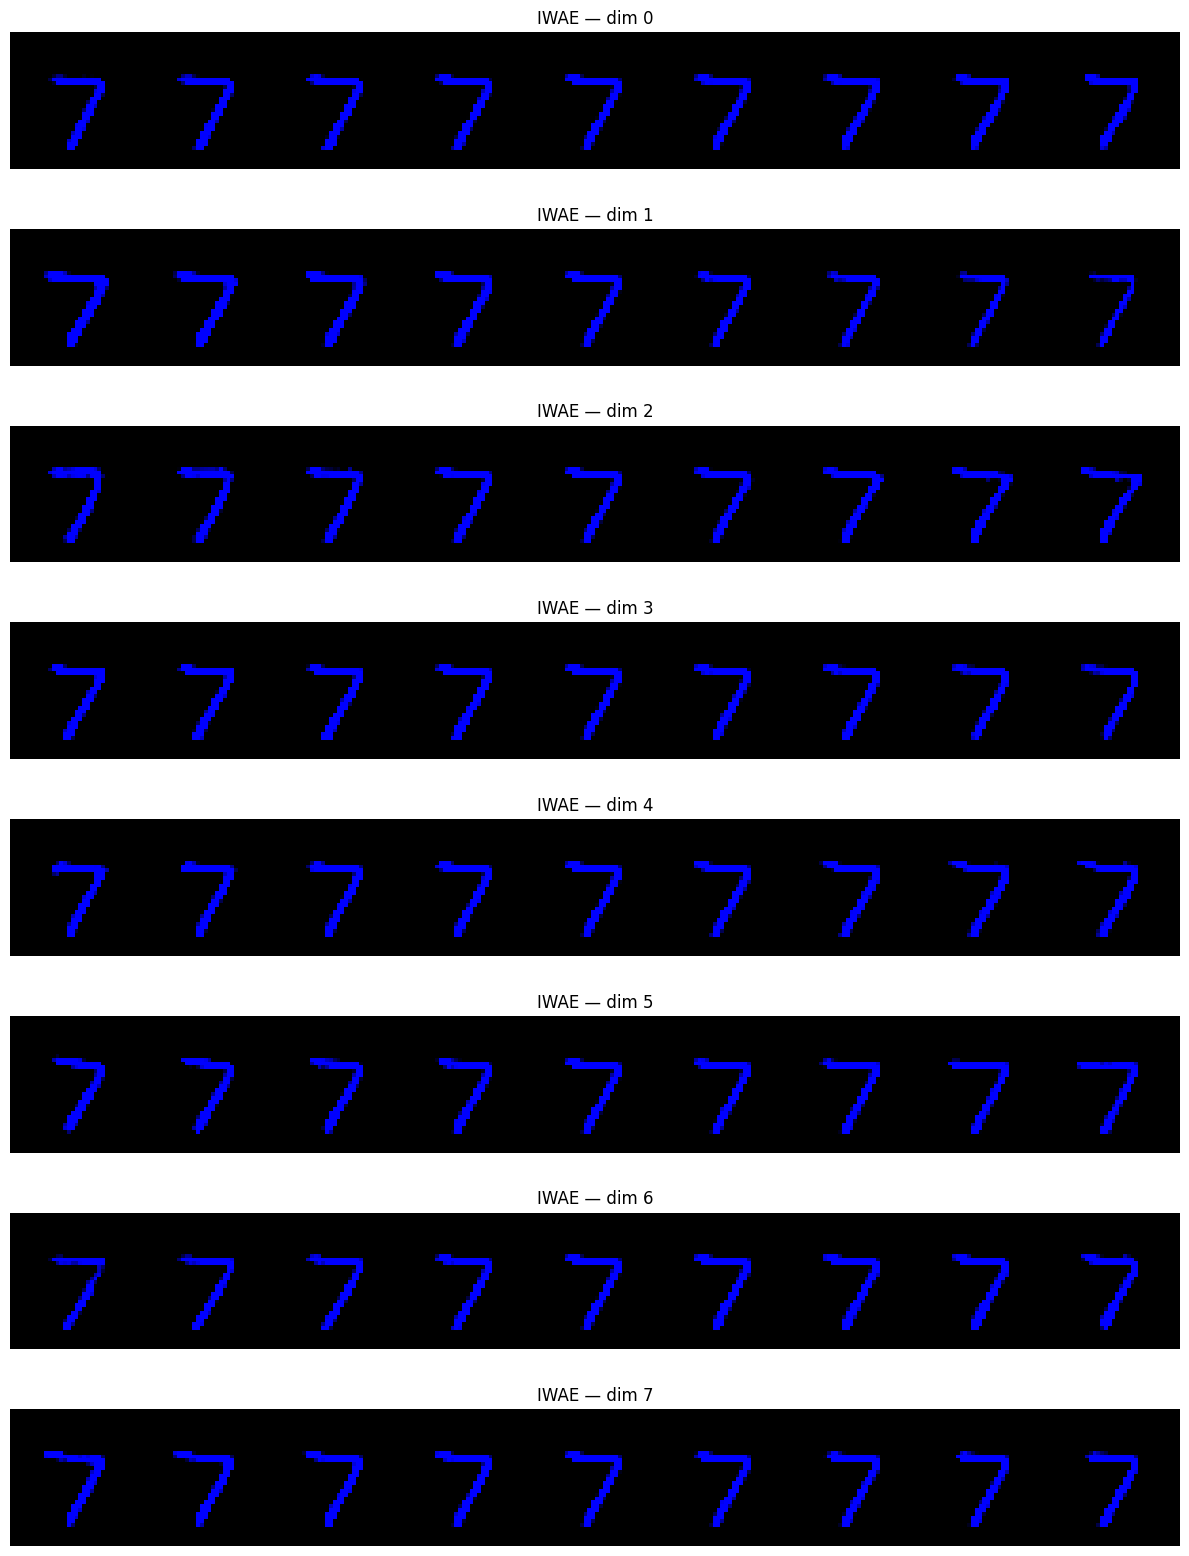

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-89.94848..3.711867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-90.18704..3.739419].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-97.01524..3.7370844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-89.850006..3.6937141].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-89.07524..3.4666557].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-91.71295..3.7709653].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-94.5388..3.6806

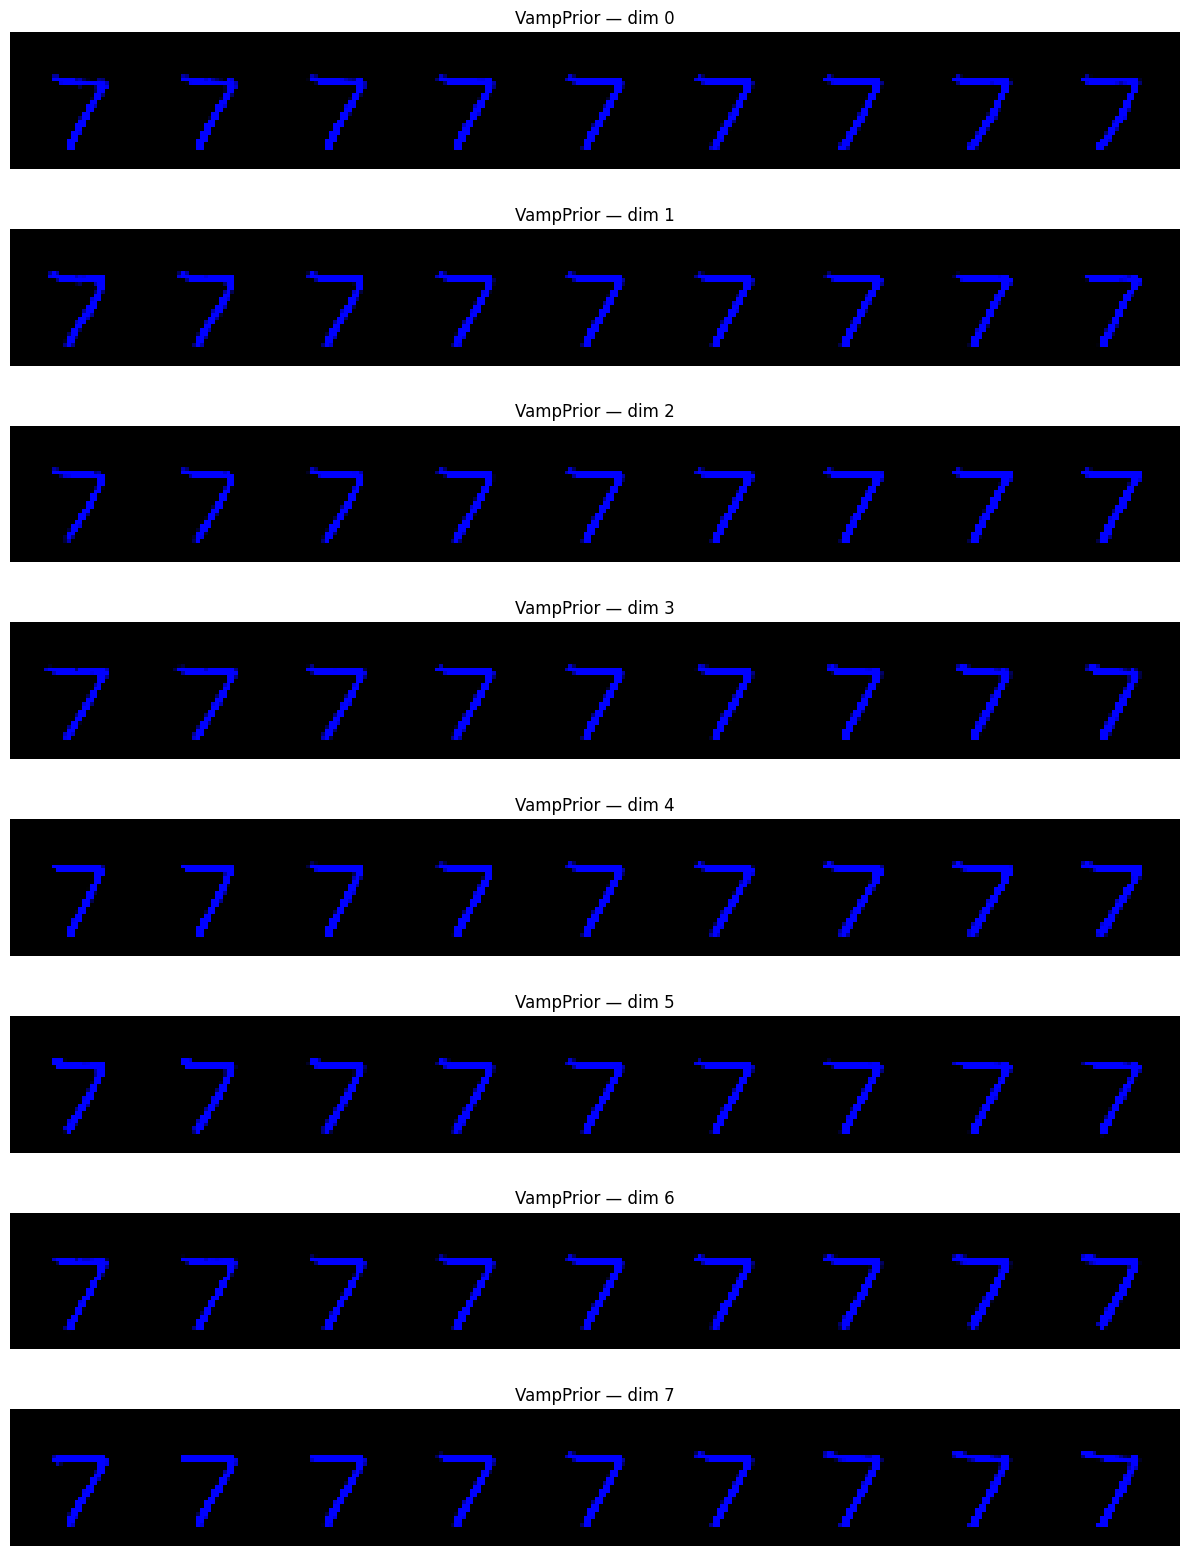

In [ ]:

def show_traversal(model, name, x0, dims=8):
    """
    Renders latent traversal for first `dims` dimensions.
    """
    fig, axes = plt.subplots(dims, 1, figsize=(12, 2*dims))

    for d in range(dims):
        imgs = latent_traversal(model, x0, dim=d, steps=9, sigma_scale=5, device=device)
        grid = make_grid(imgs, nrow=9)

        axes[d].imshow(grid.permute(1,2,0))
        axes[d].axis("off")
        axes[d].set_title(f"{name} — dim {d}")

    plt.tight_layout()
    plt.show()


# pick 1 sample
x0, _ = next(iter(val_dl))
x0 = x0[:1].to(device)


# run traversal for all models
for name, model in MODELS.items():
    show_traversal(model, name, x0, dims=8)



MODEL:  VAE


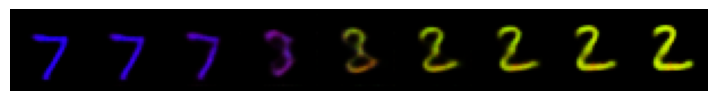

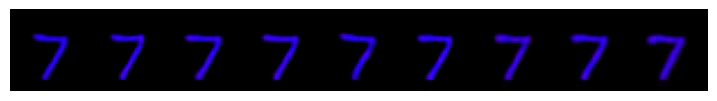

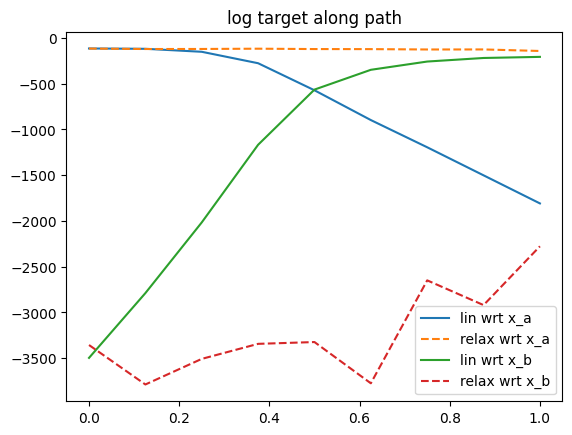

acceptances per segment: [0.98, 0.96, 0.92, 0.97, 0.87, 0.86, 0.51, 0.53, 0.55]
MODEL:  IWAE


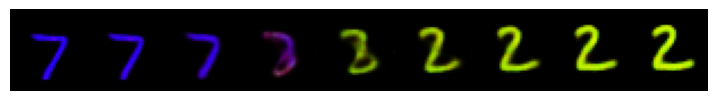

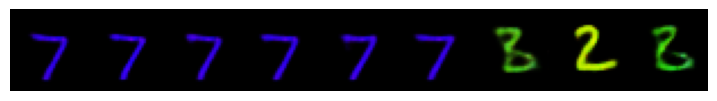

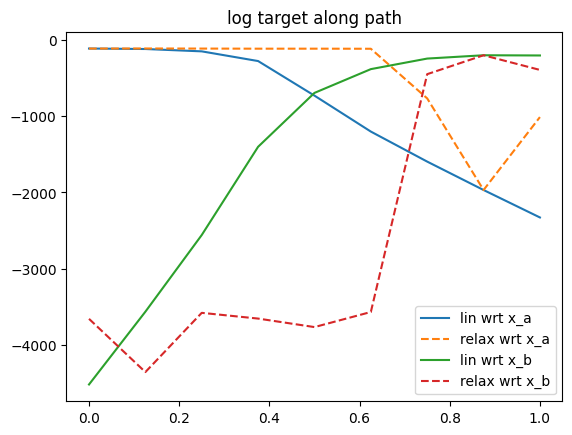

acceptances per segment: [0.98, 0.94, 0.93, 0.91, 0.94, 0.88, 0.01, 0.0, 0.02]
MODEL:  VampPrior


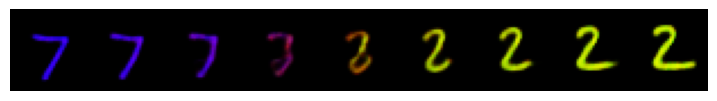

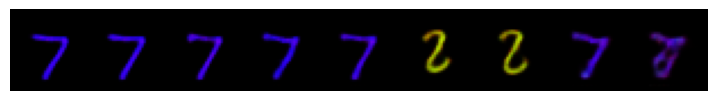

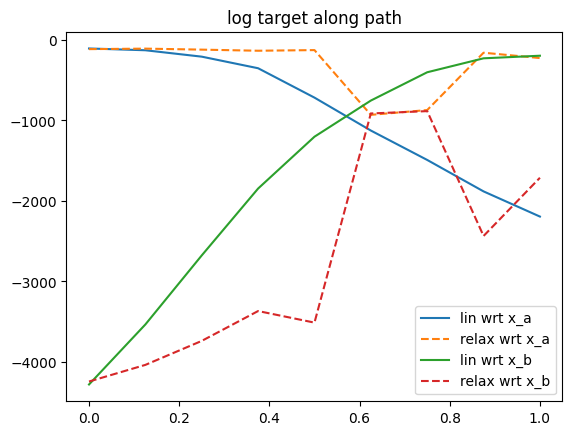

acceptances per segment: [0.96, 0.95, 1.0, 0.99, 0.99, 0.02, 0.08, 0.93, 0.94]


In [ ]:
 for name, model in MODELS.items():
    print("MODEL: ", name)
    # выбери пару изображений из val_dl
    x_batch, y_batch = next(iter(val_dl))
    x_a = x_batch[0:1].to(default_device)
    x_b = x_batch[1:2].to(default_device)

    # латенты (используем mu)
    mu_a, logvar_a = model.encoder(x_a)
    mu_b, logvar_b = model.encoder(x_b)
    z_a = mu_a.squeeze(0).cpu()
    z_b = mu_b.squeeze(0).cpu()

    # запустить для каждой модели
    ts, z_lin, z_relaxed, logs, accs = mcmc_relaxed_interpolation(model, x_a.squeeze(0), x_b.squeeze(0), z_a, z_b, n_t=9, n_relax=100, eps=0.05)

    # show linear decoded images
    decode_grid(z_lin, model)
    # show relaxed decoded images
    decode_grid(z_relaxed, model)

    # plot log-targets
    logp_lin_a, logp_rel_a, logp_lin_b, logp_rel_b = logs
    plt.plot(ts, logp_lin_a, label='lin wrt x_a')
    plt.plot(ts, logp_rel_a, '--', label='relax wrt x_a')
    plt.plot(ts, logp_lin_b, label='lin wrt x_b')
    plt.plot(ts, logp_rel_b, '--', label='relax wrt x_b')
    plt.legend(); plt.title('log target along path'); plt.show()

    print('acceptances per segment:', accs)
